In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

num_fil = 4

# Update this path to your planar simulation file
true_states_file = Path(
    f"../data/{num_fil}_wall_tilt1.0_spacing0.12_0/20260401/"
    f"ciliate_{num_fil}fil_40962blob_8.00R_0.1500torsion_0.2182tilt_0.3000f_eff_1.4960theta0_0.0000freqshift_true_states.dat"
)

# Use the value from your simulation setup
steps_per_period = 500

# If True, also include pair (last, first)
include_wraparound = False

Ordered filament IDs along line: [1, 2, 3, 4]
Plotted neighbour pairs: ['1-2', '2-3', '3-4']


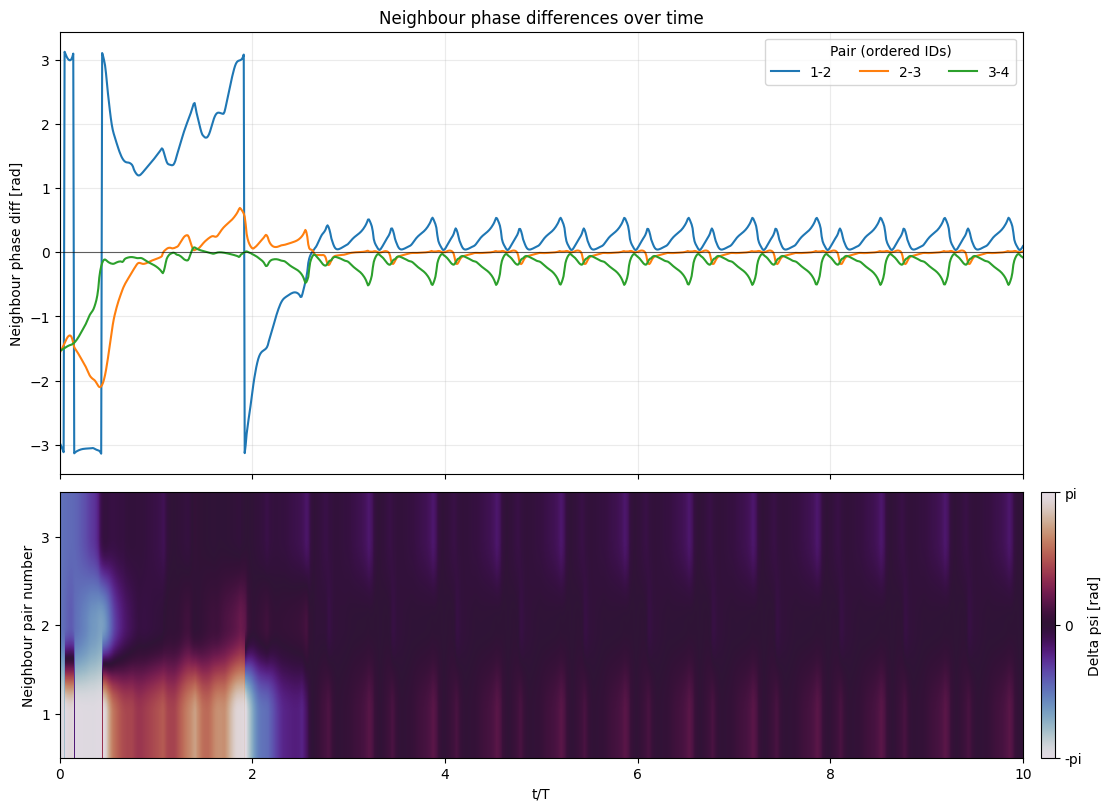

In [6]:
def wrap_to_pi(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


def load_true_states(path, steps_per_period):
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    ncol = data.shape[1]
    if ncol < 4 or (ncol - 2) % 2 != 0:
        raise ValueError(f"Unexpected column count in {path}: {ncol}")

    nfil = (ncol - 2) // 2
    step = data[:, 0]
    period = data[:, 1]
    phases = data[:, 2 : 2 + nfil]  # psi columns

    t_over_T = step / float(steps_per_period)
    t = t_over_T * period
    return t, t_over_T, phases, nfil


def infer_line_order_from_references(true_states_path, nfil):
    ref_path = Path(str(true_states_path).replace("_true_states.dat", "_fil_references.dat"))
    if not ref_path.exists():
        print(f"[warn] Reference file not found, using file-order indices: {ref_path}")
        order = np.arange(nfil)
        return order, None, None

    raw = np.loadtxt(ref_path).reshape(-1)
    if raw.size % 3 != 0:
        raise ValueError(f"Reference file size not divisible by 3: {ref_path}")

    refs = raw.reshape(-1, 3)
    if refs.shape[0] < nfil:
        raise ValueError(f"Reference file has fewer filaments than true_states: {ref_path}")

    refs = refs[:nfil, :]
    xy = refs[:, :2]
    centered = xy - xy.mean(axis=0, keepdims=True)

    # Principal-axis projection gives robust linear ordering even if the line is tilted in x-y.
    if np.linalg.norm(centered) < 1e-14:
        axis = np.array([1.0, 0.0])
    else:
        _, _, vt = np.linalg.svd(centered, full_matrices=False)
        axis = vt[0]

    proj = centered @ axis
    order = np.argsort(proj)
    return order, proj, refs


# Load data
t, t_over_T, phases, nfil = load_true_states(true_states_file, steps_per_period)
if nfil < 2:
    raise ValueError("Need at least 2 filaments to form neighbour phase differences.")

order, proj, refs = infer_line_order_from_references(true_states_file, nfil)
phases_ord = phases[:, order]
fil_ids = order + 1  # 1-based filament IDs for labels

# Compute neighbour phase differences
diffs = []
labels = []

for i in range(nfil - 1):
    diffs.append(wrap_to_pi(phases_ord[:, i + 1] - phases_ord[:, i]))
    labels.append(f"{fil_ids[i]}-{fil_ids[i+1]}")

if include_wraparound:
    diffs.append(wrap_to_pi(phases_ord[:, 0] - phases_ord[:, -1]))
    labels.append(f"{fil_ids[-1]}-{fil_ids[0]}")

dpsi = np.column_stack(diffs)  # shape: (time, neighbour_pairs)

# Plot
fig, axes = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.2]},
    constrained_layout=True
)

# Line plot for each neighbour pair
for k, lbl in enumerate(labels):
    axes[0].plot(t_over_T, dpsi[:, k], lw=1.5, label=lbl)

axes[0].axhline(0.0, color="k", lw=0.8, alpha=0.6)
axes[0].set_ylabel("Neighbour phase diff [rad]")
axes[0].set_title("Neighbour phase differences over time")
axes[0].grid(alpha=0.25)
axes[0].legend(title="Pair (ordered IDs)", ncol=min(4, max(1, len(labels))))

# Heatmap view
im = axes[1].imshow(
    dpsi.T,
    origin="lower",
    aspect="auto",
    extent=[t_over_T[0], t_over_T[-1], 0.5, dpsi.shape[1] + 0.5],
    cmap="twilight",
    vmin=-np.pi,
    vmax=np.pi
)
axes[1].set_xlabel("t/T")
axes[1].set_ylabel("Neighbour pair number")
axes[1].set_yticks(np.arange(1, dpsi.shape[1] + 1))

cbar = fig.colorbar(im, ax=axes[1], pad=0.01)
cbar.set_label("Delta psi [rad]")
cbar.set_ticks([-np.pi, 0.0, np.pi])
cbar.set_ticklabels(["-pi", "0", "pi"])

print("Ordered filament IDs along line:", fil_ids.tolist())
print("Plotted neighbour pairs:", labels)